In [1]:
# Python Libs
import numpy as np
import matplotlib.pyplot as plt
import time
plt.style.use('dark_background')

# import pwi_inst.hardware.Cameras.FirstlightCameras.FirstLightCblue2 as CamLib
# import pwi_inst.hardware.Cameras.FirstlightCameras.FirstLightCred3_2Lite as CamLib
import pwi_inst.hardware.Cameras.FLIRPointGreyCameras.FLIR_PointGrey as CamLib
import pwi_inst.hardware.Cameras.Camera_Client as CamClientlib
import pwi_inst.hardware.Cameras.Camera_Server as CamServerlib 
import pwi_inst.hardware.Cameras.Camera_Viewer as CamViewerlib 




In [2]:
%load_ext autoreload
%aimport pwi_inst.hardware.Cameras.FLIRPointGreyCameras.flir_flycapture2_ctypes
%aimport pwi_inst.hardware.Cameras.FLIRPointGreyCameras.FLIR_PointGrey
%aimport pwi_inst.hardware.Cameras.FirstlightCameras.FirstLightCblue2
%aimport pwi_inst.hardware.Cameras.Camera_Client
%aimport pwi_inst.hardware.Cameras.Camera_Server
%aimport pwi_inst.hardware.Cameras.Camera_Viewer
%autoreload 1

In [ ]:
# Camobject = CamLib.CameraObject(CameraIdx=0,verbose=True)


1 cameras detected:
0: FLIR camera 0
Using camera 0


In [ ]:
# Camobject.SetSoftwareTriggerMode()


('On', 'Software')

In [3]:
# Camobject = CamLib.CameraObject(CameraIdx=0,verbose=True)
camserver = CamServerlib.CameraServer(
        host="127.0.0.1",
        port=50731,
        CameraType="FLIR Point Grey",
        
        CameraKwargs={"CameraIdx": 0,"verbose": True},
        PollSleep=0.001,)
camserver.startProcess()



Camera server process started with PID 65900


1 cameras detected:
0: FLIR camera 0
Using camera 0
Camera ZMQ server running on tcp://127.0.0.1:50731
CameraType: FLIR Point Grey
Frame SHM name: psm_2992b656
Meta SHM name:  psm_6c8c1ca6
Frame shape:    (340, 372)
Frame dtype:    uint16


In [4]:
CamClient=CamClientlib.CameraClient(
        host="127.0.0.1",
        port=50731,
        timeout_ms=5000,
        client_id="camera_client")

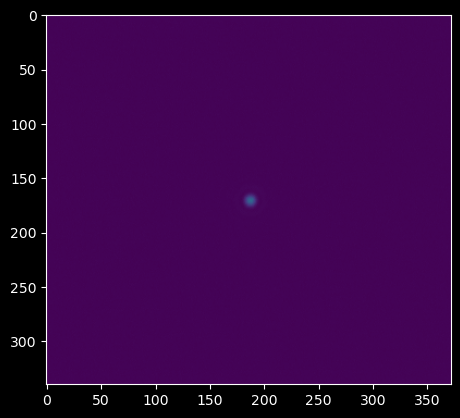

In [5]:
frame=CamClient.GetFrame()
plt.imshow(frame)

In [11]:


viewer = CamViewerlib.CameraViewer(
        host="127.0.0.1",
        port=50731,
        initial_scale=1)
viewer.startProcess()

Camera viewer started with PID 69967


QFontDatabase: Cannot find font directory /home/pllab-vis/miniforge3/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pllab-vis/miniforge3/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pllab-vis/miniforge3/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pllab-vis/miniforge3/lib/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/pllab-vi

In [10]:
viewer.stopProcess()

In [9]:
CamClient.SetExposureTime(2)

2.0114779472351074

In [8]:
CamClient.SetSoftwareTriggerMode()

['On', 'Software']

In [13]:
CamClient.GetFrame()

array([[44196,  4995, 25088, ...,   832,   960,   864],
       [  880,   928,   928, ...,   816,  1008,   880],
       [  960,   960,  1008, ...,   896,   848,   960],
       ...,
       [  880,   864,   912, ...,   912,   928,   896],
       [  800,   976,   880, ...,   896,  1008,   896],
       [  832,   912,   784, ...,   976,   864,   864]],
      shape=(340, 372), dtype=uint16)

In [15]:
CamClient.StopAcquisition()

ZMQError: Operation cannot be accomplished in current state

In [5]:
CamClient.SetContinuousMode()

Again: Resource temporarily unavailable